# Data Visualization with Matplotlib & Seaborn

> Learn how to turn data into clear, meaningful visuals.

## Why Do We Need Data Visualization?

Data analysis helps us explore and understand information. Data visualization
helps us communicate what we find by presenting data in a visual form.

Think of an algorithm as a set of steps, and a flowchart as a picture of those
steps. In the same way, charts and graphs provide a visual representation of
data, making patterns, comparisons, and trends easier to notice.

**In short:** data analysis helps us understand data; data visualization helps
us see and share that understanding.

## A Number Tells; a Chart Shows

A chart can make information easier to understand at a glance. Instead of
searching through rows of numbers, we can use visuals to quickly spot what
matters.

### Why are visuals useful?

- **Speed:** make important information quicker to understand.
- **Pattern detection:** reveal trends, relationships, and unusual values.
- **Persuasion:** present evidence clearly to support a message or decision.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

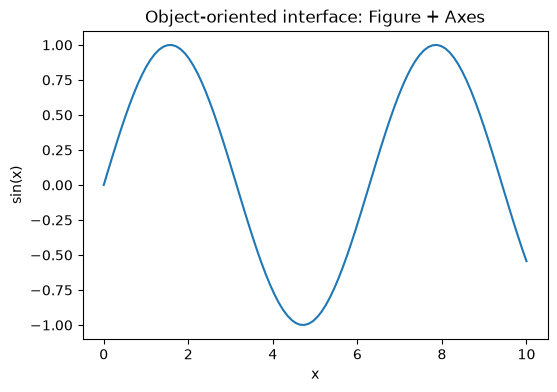

Type of fig: <class 'matplotlib.figure.Figure'>
Type of ax: <class 'matplotlib.axes._axes.Axes'>


In [32]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y)
ax.set_title("Object-oriented interface: Figure + Axes")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
plt.show()

print("Type of fig:", type(fig))
print("Type of ax:", type(ax))

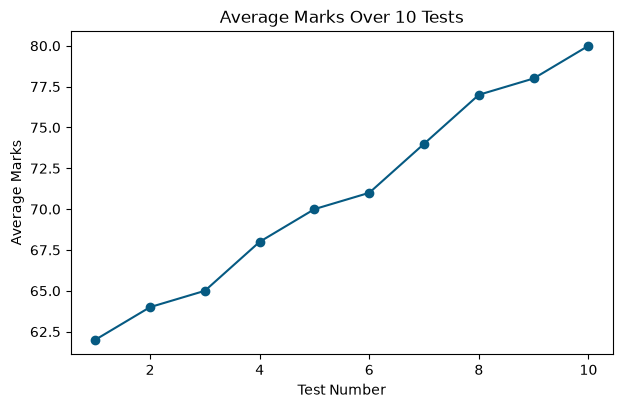

In [33]:
"""
days = list(range(1,11))
avg = [62,64,65,68,70,71,74,77,78]

fig, ax = plt.subplots(figsize=(7,4.2))
ax.plot(days,avg,marker="o",color="#065A82")

ax.set_title("avg marks over 10 Tests")

ax.set_xlabel("Test Number")

ax.set_ylabel("Average Marks")

plt.show()
"""

days = list(range(1, 11))

avg = [62, 64, 65, 68, 70, 71, 74, 77, 78, 80]

fig, ax = plt.subplots(figsize=(7, 4.2))

ax.plot(days, avg, marker="o", color="#065A82")

ax.set_title("Average Marks Over 10 Tests")
ax.set_xlabel("Test Number")
ax.set_ylabel("Average Marks")

plt.show()

In [34]:
df = pd.read_csv("./web_traffic_daily.csv")
display(df.head())
display(df.isna().sum())
display(df.isnull().sum())
display(df.duplicated().sum())
display(df.shape)
display(df.size)
display(df.dtypes)
df['date'] = pd.to_datetime(df['date'],format="%d-%m-%Y")


,date,visits,signups,page_load_ms,error_count,deployment_flag
0,01-01-2025,1258,78,218.1,2,0
1,02-01-2025,1181,52,211.0,4,0
2,03-01-2025,1292,56,219.9,1,0
3,04-01-2025,1017,52,206.6,5,0
4,05-01-2025,847,48,215.0,4,0


date               0
visits             0
signups            0
page_load_ms       0
error_count        0
deployment_flag    0
dtype: int64

date               0
visits             0
signups            0
page_load_ms       0
error_count        0
deployment_flag    0
dtype: int64

np.int64(0)

(365, 6)

2190

date                   str
visits               int64
signups              int64
page_load_ms       float64
error_count          int64
deployment_flag      int64
dtype: object

### How Did The Number of Visitors to our website change over one year ?

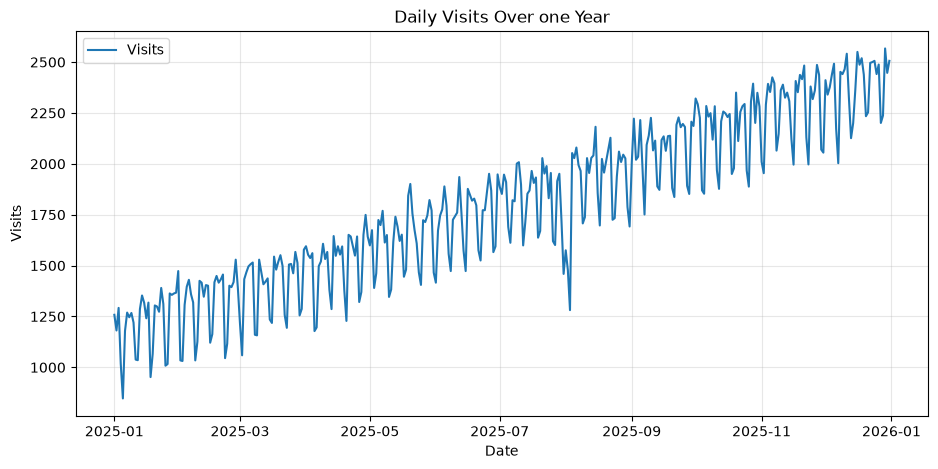

In [35]:
fig,ax = plt.subplots(figsize=(11,5))
ax.plot(df['date'],df['visits'],color="tab:blue",linewidth=1.5,label="Visits")
ax.set_title("Daily Visits Over one Year")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlabel("Date")
ax.set_ylabel("Visits")
fig.savefig("visits.png",dpi=1600,bbox_inches="tight")

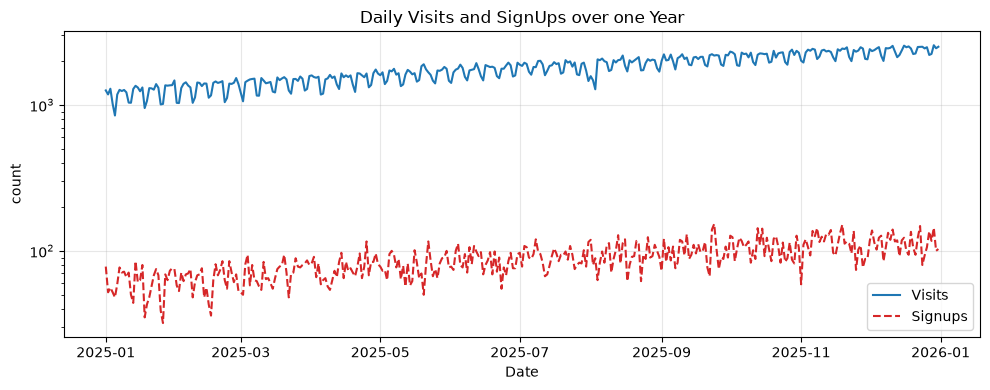

In [36]:
fig,ax = plt.subplots(figsize=(10,4))
ax.plot(
    df['date'],
    df['visits'],
    color="tab:blue",
    linestyle="-",
    label="Visits"
)
ax.plot(
    df['date'],
    df['signups'],
    color="tab:red",
    linestyle="--",
    label="Signups"
)

ax.set_title("Daily Visits and SignUps over one Year")
ax.set_xlabel("Date")
ax.set_ylabel("count")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

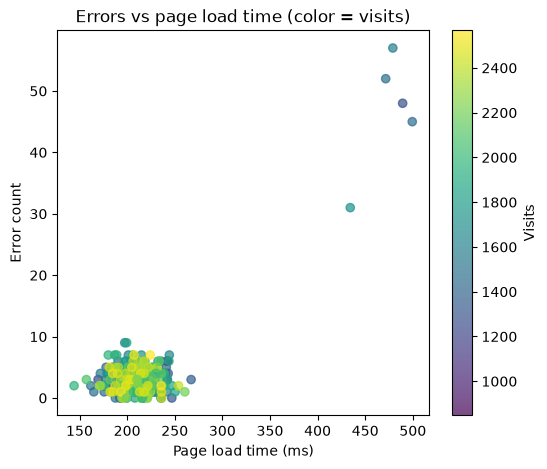

In [37]:
fig,ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(df['page_load_ms'],df['error_count'],c=df['visits'],cmap="viridis",alpha=0.7)
ax.set_title("Errors vs page load time (color = visits)")
ax.set_xlabel("Page load time (ms)")
ax.set_ylabel("Error count")
fig.colorbar(sc,ax=ax,label="Visits")
plt.show()

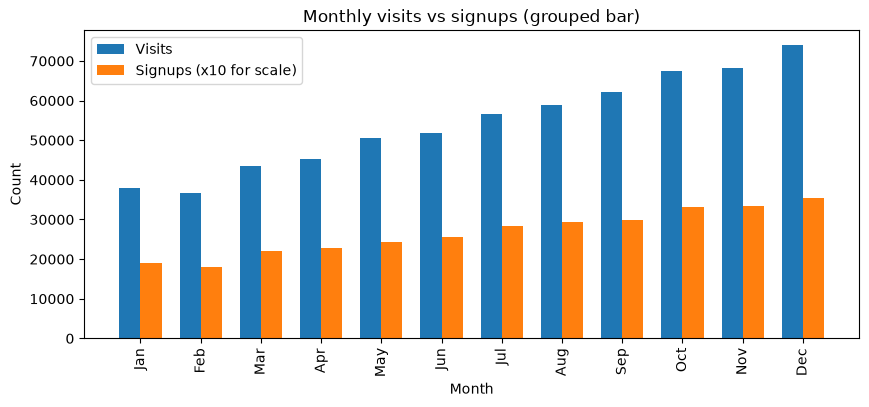

In [38]:
monthly = df.set_index("date").resample("ME")[["visits", "signups"]].sum()
monthly.index = monthly.index.strftime("%b")

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(monthly))
width = 0.35

ax.bar(x - width/2, monthly["visits"], width, label="Visits")
ax.bar(x + width/2, monthly["signups"] * 10, width, label="Signups (x10 for scale)")
ax.set_xticks(x)
ax.set_xticklabels(monthly.index, rotation=90)
ax.set_title("Monthly visits vs signups (grouped bar)")
ax.set_xlabel("Month")
ax.set_ylabel("Count")
ax.legend() 
plt.show()

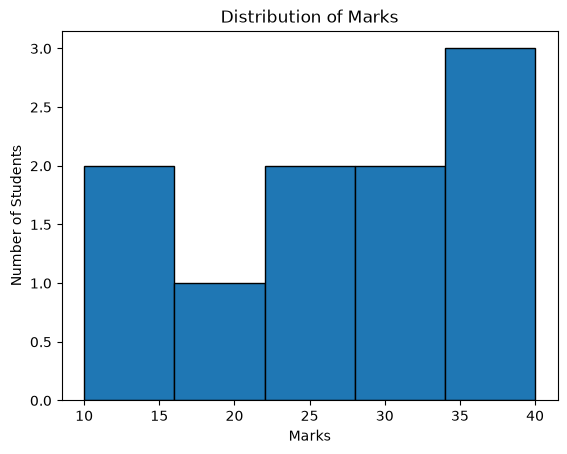

In [39]:
# Histogram is used to distribute a single column
marks = [10,15,18,22,25,28,31,35,38,40]
plt.hist(marks,bins=5,edgecolor="black")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.title("Distribution of Marks")
plt.show()

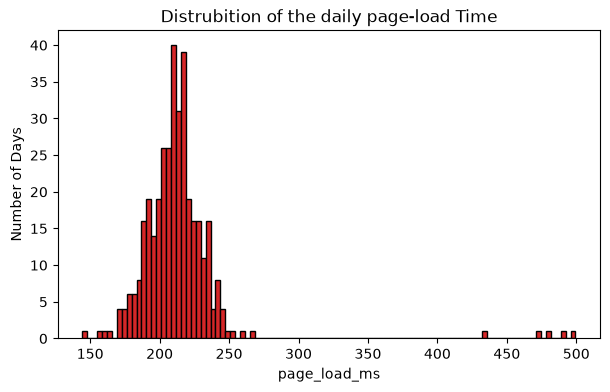

In [40]:
# What is the ususal page loading time of the website using histogram 
plt.figure(figsize=(7,4))
plt.hist(df['page_load_ms'],bins=100,color="tab:red",edgecolor="black")
plt.xlabel("page_load_ms")
plt.ylabel("Number of Days")
plt.title("Distrubition of the daily page-load Time")
plt.show()

/tmp/ipykernel_14692/4168634758.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['error_count'],vert=True,patch_artist=True,boxprops=dict(facecolor="green"))


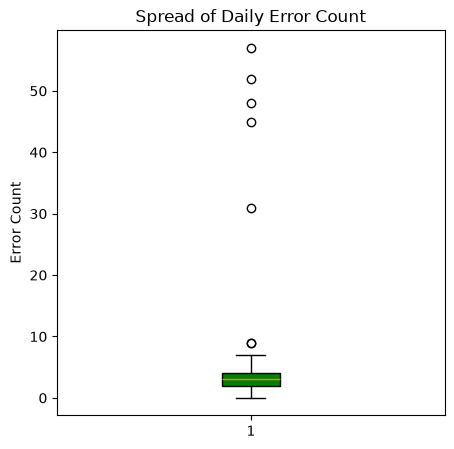

In [41]:
plt.figure(figsize=(5,5))
plt.boxplot(df['error_count'],vert=True,patch_artist=True,boxprops=dict(facecolor="green"))
plt.title("Spread of Daily Error Count")
plt.ylabel("Error Count")
plt.show()


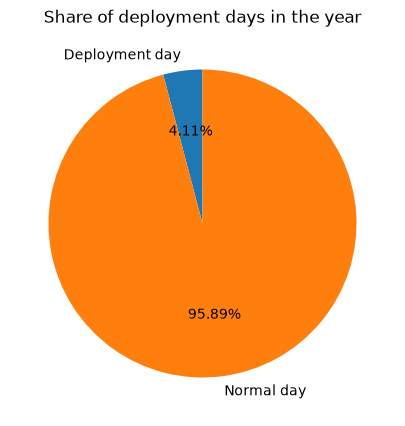

In [42]:
deploy_days = df["deployment_flag"].sum()
normal_days = len(df) - deploy_days

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([deploy_days, normal_days],
       labels=["Deployment day", "Normal day"],
       autopct="%1.2f%%", startangle=90)
ax.set_title("Share of deployment days in the year")
plt.show()

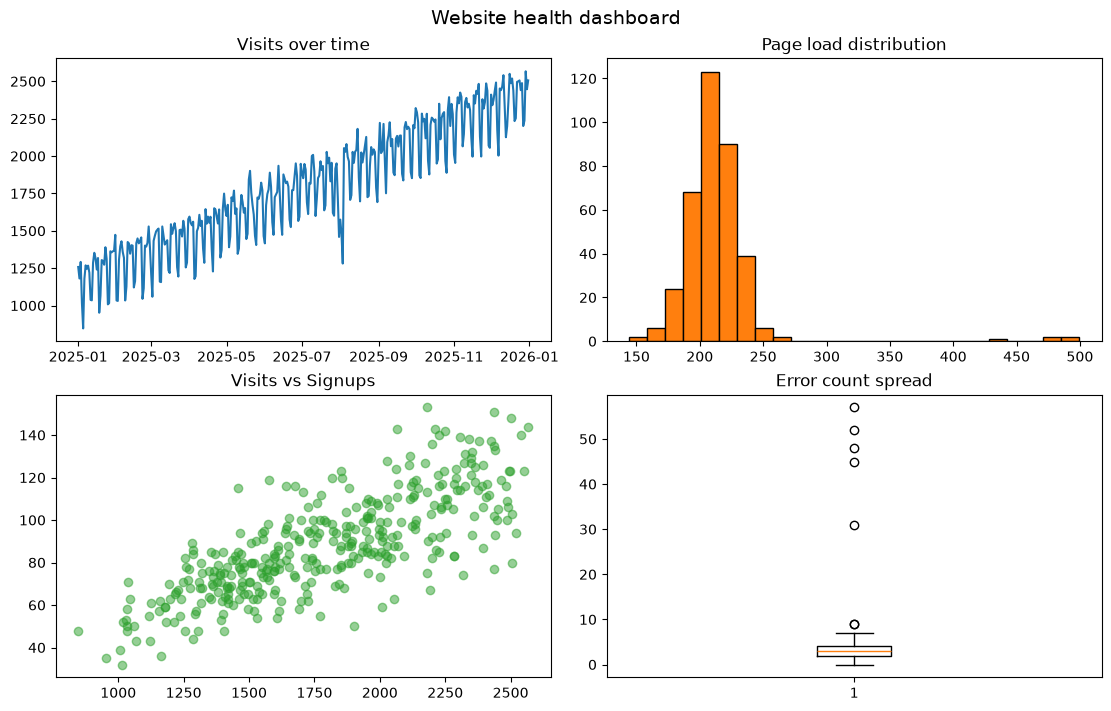

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
 
axes[0, 0].plot(df["date"], df["visits"], color="tab:blue")
axes[0, 0].set_title("Visits over time")
 
axes[0, 1].hist(df["page_load_ms"], bins=25, color="tab:orange",edgecolor="black")
axes[0, 1].set_title("Page load distribution")
 
axes[1, 0].scatter(df["visits"], df["signups"], alpha=0.5, color="tab:green")
axes[1, 0].set_title("Visits vs Signups")
 
axes[1, 1].boxplot(df["error_count"])
axes[1, 1].set_title("Error count spread")
 
fig.suptitle("Website health dashboard", fontsize=14)
plt.show()
 
# Try this: change to plt.subplots(1, 4, figsize=(18, 4)) and index axes as axes[0], axes[1], ...

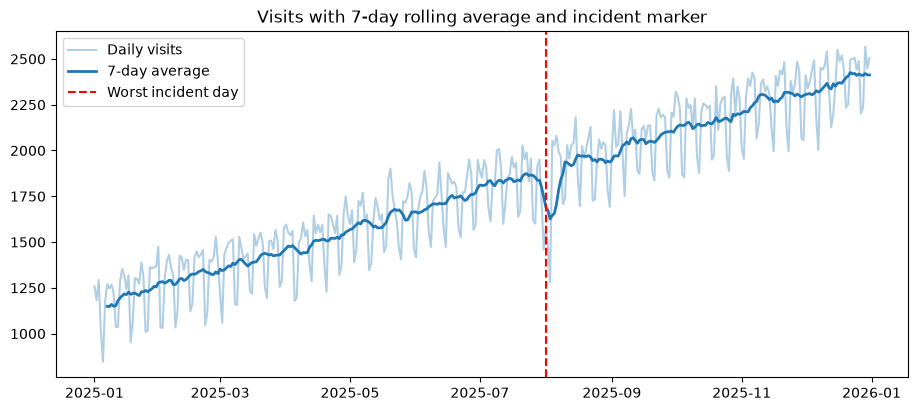

In [44]:
df["visits_7d_avg"] = df["visits"].rolling(7).mean()
incident_date = df.loc[df["error_count"].idxmax(), "date"]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df["date"], df["visits"], alpha=0.35, label="Daily visits")
ax.plot(df["date"], df["visits_7d_avg"], color="tab:blue", linewidth=2, label="7-day average")
ax.axvline(incident_date, color="red", linestyle="--", label="Worst incident day")
ax.set_title("Visits with 7-day rolling average and incident marker")
ax.legend()
plt.show()

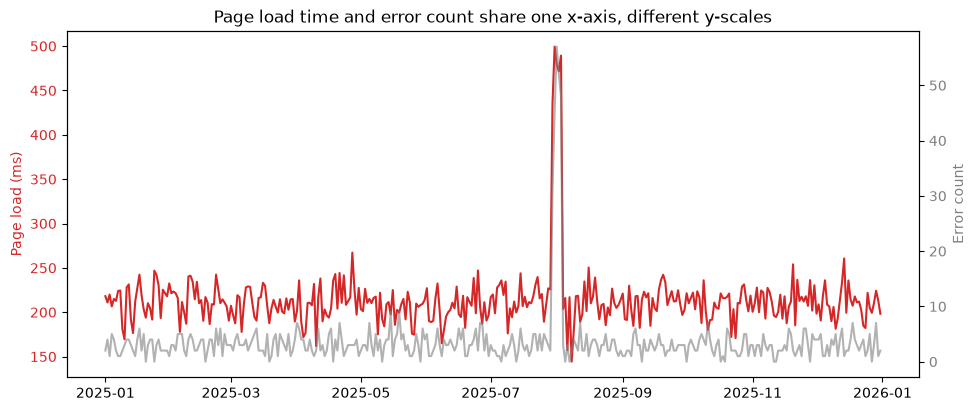

In [45]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))
 
ax1.plot(df["date"], df["page_load_ms"], color="tab:red")
ax1.set_ylabel("Page load (ms)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
 
ax2 = ax1.twinx()
ax2.plot(df["date"], df["error_count"], color="tab:gray", alpha=0.6)
ax2.set_ylabel("Error count", color="tab:gray")
ax2.tick_params(axis="y", labelcolor="tab:gray")
 
ax1.set_title("Page load time and error count share one x-axis, different y-scales")
plt.show()
 

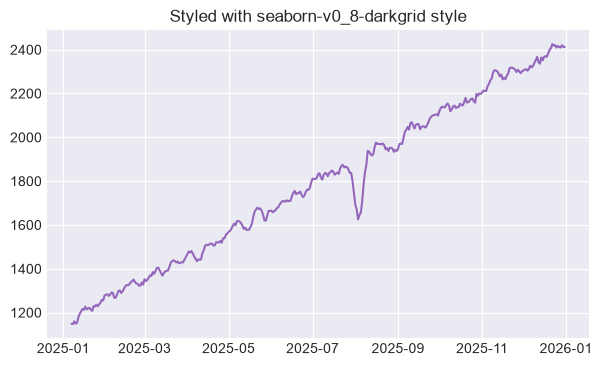

In [46]:
"""
['Solarize_Light2',
'bmh',
'classic',
'dark_background',
'fast',
'ggplot',
'grayscale',
'seaborn-v0_8-darkgrid']

Styles in matplotlib
"""
with plt.style.context("seaborn-v0_8-darkgrid"):
    fig,ax = plt.subplots(figsize=(7,4))
    ax.plot(df['date'],df['visits_7d_avg'],color="tab:purple")
    ax.set_title("Styled with seaborn-v0_8-darkgrid style")
    plt.show()



# Quick Revision - Matplotlib
 
- **Object model:** `Figure` (canvas) → `Axes` (a plot) → `Axis` (x or y) → `Artist` (everything drawn). Prefer the OO interface: `fig, ax = plt.subplots()`.
- **Line plot:** `ax.plot(x, y, color=, linestyle=, marker=, label=)`
- **Scatter:** `ax.scatter(x, y, c=, cmap=, alpha=)` - for relationships between two numeric variables
- **Bar:** `ax.bar(x, height)` - grouped with an offset, stacked with `bottom=`
- **Histogram:** `ax.hist(data, bins=)` - for distributions
- **Box plot:** `ax.boxplot(data)` - median, IQR, outliers
- **Subplots:** `fig, axes = plt.subplots(nrows, ncols, figsize=, constrained_layout=True)`
- **Time series helpers:** `.rolling(n).mean()`, `ax.axvline()`, `ax.fill_between()`, `ax.twinx()`
- **Styling:** `plt.style.use(...)`, colour-blind-friendly cmaps (`viridis`, `coolwarm`)
- **Saving:** `fig.savefig("name.png", dpi=300, bbox_inches="tight")`
- **Beware:** truncated axes, too many pie slices, missing labels, overplotting